# 3. Geometric Patterns and Symmetry

Today the dice rest. We build ornament from pure rule: sine and cosine place points on circles, rotation and reflection multiply a motif, and two nested loops repeat it across the plane until it becomes a pattern.

## Today's destination

A full-page star-and-hexagon tiling in the tradition of Islamic geometric ornament: six-pointed stars, each nested among hexagons, repeating without end. Everything in it is built from one humble function that places the corners of a polygon on a circle, and you will write that function yourself in the next half hour.

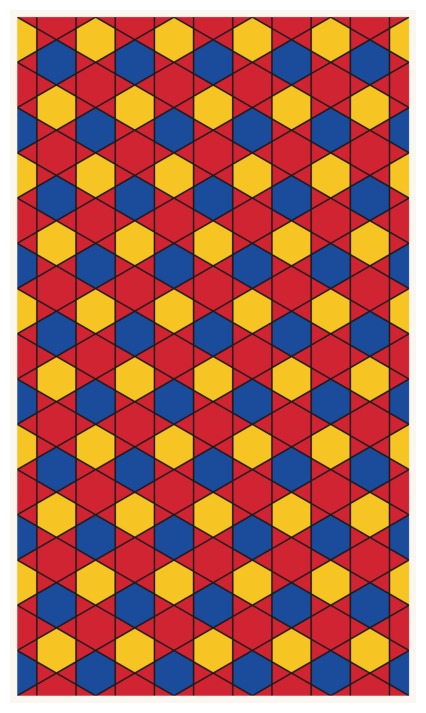

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch03_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(7, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: ornament as calculated beauty

Walk through the **Alhambra** in Granada, the palace complex the Nasrid dynasty built in the 13th and 14th centuries, and you walk through mathematics: walls of glazed *zellij* tilework where stars, crosses, and interlacing bands repeat with perfect regularity in every direction. The craftsmen who designed them worked with compass and straightedge, not equations, yet they explored planar symmetry so thoroughly that mathematicians still argue about how many of its possible types the Alhambra realizes. In much of Islamic religious art, figurative images were avoided; geometry was not a limitation but the chosen path, ornament (Ornament) elevated to the highest art.

How were such patterns designed and transmitted? A rare surviving clue is the **Topkapı scroll** (late 15th or early 16th century, Timurid-Turkmen Iran), nearly thirty meters of construction drawings for star patterns and vaults: a pattern *cookbook*, instructions rather than pictures, which should remind you of Sol LeWitt from chapter 1. In 2007 the physicists Peter Lu and Paul Steinhardt argued in *Science* that medieval designers worked with a set of five puzzle-piece tiles, the so-called *girih* tiles, and that one 15th-century shrine facade uses them in a quasi-periodic arrangement of a kind mathematics only formalized with Roger Penrose in the 1970s. The claim remains debated, but the lesson stands: this craft tradition encoded serious geometry centuries before the theory existed.

Europe studied this tradition closely. The architect **Owen Jones** measured the Alhambra in the 1830s and distilled what he learned into *The Grammar of Ornament* (1856), a chromolithographed atlas of pattern from nineteen historical styles, prefaced by 37 general "propositions": rules for good ornament. A grammar of form, stated as rules: Jones was writing generative systems a century before computers. And in 1922 and again in 1936, a young Dutch graphic artist named **M. C. Escher** visited the Alhambra, copied its tilings into sketchbooks with his wife Jetta, and spent the rest of his career on what he called the *regular division of the plane*, trading letters with mathematicians along the way.

The mathematics underneath is beautiful and finite: combining rotations, reflections, translations, and glide reflections, there are exactly **17** possible symmetry types of wallpaper pattern (the wallpaper groups, Ornamentgruppen), no more, in any culture, on any planet. We will not enumerate them; we will build machines that produce a few. Note what is missing today: chance. Like chapter 0's stripes, and unlike everything in between, today's systems are fully deterministic, and the beauty survives just fine.

## The circle: sine and cosine

All of today's geometry stands on one formula. To place a point on a circle of radius $r$ around a center $(c_x, c_y)$, at an angle $\alpha$:

$$x = c_x + r\cos\alpha \qquad y = c_y + r\sin\alpha$$

That is all sine and cosine will mean for us: **cosine is the x-coordinate, sine is the y-coordinate of a point on a circle.** Angles are measured counterclockwise from the positive x-axis, and Python's `math` module wants them in *radians*; `math.radians(45)` converts from degrees. The diagram below shows the formula at work for three angles.

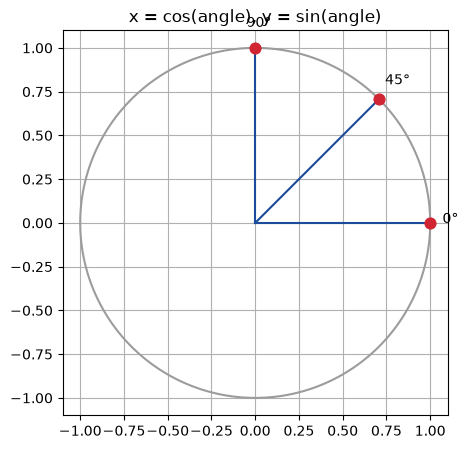

In [2]:
# three points on the unit circle, at 0, 45 and 90 degrees -- axes ON, diagram
# (np.cos works on a whole array at once; math.cos on a single number)
import math
import numpy as np

circle_angles = np.linspace(0, 2 * math.pi, 200)
plt.figure(figsize=(5, 5))
plt.plot(np.cos(circle_angles), np.sin(circle_angles), color="#9C9C9C")
for degrees in [0, 45, 90]:
    a = math.radians(degrees)
    plt.plot([0, math.cos(a)], [0, math.sin(a)], color="#1B4B9B")
    plt.scatter([math.cos(a)], [math.sin(a)], s=60, color="#D02433", zorder=3)
    plt.text(1.12 * math.cos(a) - 0.05, 1.12 * math.sin(a), f"{degrees}°")
plt.grid(True)
plt.gca().set_aspect("equal")
plt.title("x = cos(angle), y = sin(angle)")
plt.show()

## Regular polygons

A regular polygon is just $n$ points on a circle, evenly spaced: corner number $k$ sits at the angle

$$\alpha_k = \text{rotation} + \frac{2\pi k}{n}$$

and we connect the corners in order. (Chapter 1's `square_corners` was secretly doing exactly this, with $n = 4$; now the trick gets its proper name.) The function below is the workhorse of the whole chapter: it returns the corner coordinates of any regular polygon, anywhere, at any size and rotation. Note that it appends the first corner again at the end, so the outline closes.

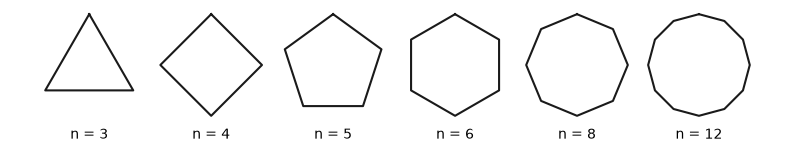

In [3]:
# the corners of a regular n-gon on a circle -- the workhorse of this chapter
def polygon_points(cx, cy, radius, n_sides, rotation=0.0):
    xs = []
    ys = []
    for k in range(n_sides + 1):          # n_sides + 1 closes the outline
        angle = rotation + 2 * math.pi * k / n_sides
        xs.append(cx + radius * math.cos(angle))
        ys.append(cy + radius * math.sin(angle))
    return xs, ys

# a row of polygons, from triangle to twelve-gon
plt.figure(figsize=(10, 2.4))
for position, n_sides in [(0, 3), (1, 4), (2, 5), (3, 6), (4, 8), (5, 12)]:
    xs, ys = polygon_points(position * 2.4, 0, 1.0, n_sides, rotation=math.pi / 2)
    plt.plot(xs, ys, color="#1A1A1A", linewidth=1.5)
    plt.text(position * 2.4, -1.45, f"n = {n_sides}", ha="center")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.show()

## Star polygons

Now a small change with a large effect: place $n$ points on the circle as before, but connect **every k-th point** instead of every neighbor. Geometers write this as $\{n/k\}$: the pentagram is $\{5/2\}$, five points connected two steps at a time. The drawing order jumps around the circle, and the crossings create the star.

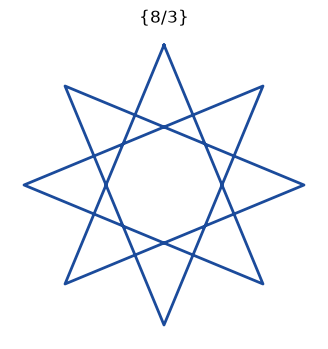

In [4]:
# a star polygon {n/k}: connect every k-th of n points on a circle
def star_polygon_points(cx, cy, radius, n, k, rotation=0.0):
    xs = []
    ys = []
    for i in range(n + 1):                # visit n corners, then close
        corner = (i * k) % n              # jump k corners; % wraps around the clock
        angle = rotation + 2 * math.pi * corner / n
        xs.append(cx + radius * math.cos(angle))
        ys.append(cy + radius * math.sin(angle))
    return xs, ys

plt.figure(figsize=(4, 4))
xs, ys = star_polygon_points(0, 0, 1.0, 8, 3, rotation=math.pi / 2)
plt.plot(xs, ys, color="#1B4B9B", linewidth=2)
plt.gca().set_aspect("equal")
plt.axis("off")
plt.title("{8/3}")
plt.show()

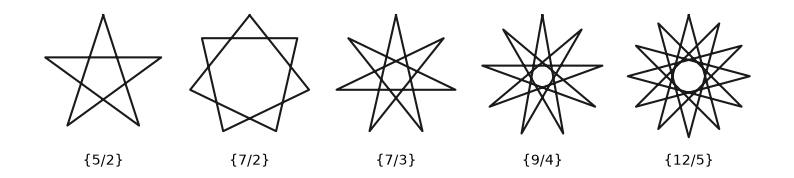

In [5]:
# a small zoo of star polygons
plt.figure(figsize=(10, 2.4))
for position, n, k in [(0, 5, 2), (1, 7, 2), (2, 7, 3), (3, 9, 4), (4, 12, 5)]:
    xs, ys = star_polygon_points(position * 2.4, 0, 1.0, n, k, rotation=math.pi / 2)
    plt.plot(xs, ys, color="#1A1A1A", linewidth=1.5)
    plt.text(position * 2.4, -1.45, "{" + f"{n}/{k}" + "}", ha="center")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.show()

**Try it.** The slider cell below sweeps $n$ and $k$ live (where widgets do not run, plain calls to `star_explorer` do the same). Find a star the zoo missed, and note what happens when $k$ divides $n$: a snag we will need in a moment.

In [6]:
# optional sliders -- everything they do, the plain function calls above do too
def star_explorer(n=8, k=3, rotation=0.0):
    plt.figure(figsize=(5, 5))
    xs, ys = star_polygon_points(0, 0, 1.0, n, k, rotation)
    plt.plot(xs, ys, color="#1B4B9B", linewidth=2)
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.title("{" + f"{n}/{k}" + "}")
    plt.show()

try:
    from ipywidgets import interact
    interact(star_explorer, n=(3, 16), k=(1, 8), rotation=(0.0, 6.3, 0.1))
except ImportError:
    print("ipywidgets is not installed -- call star_explorer(n, k, rotation) directly")

interactive(children=(IntSlider(value=8, description='n', max=16, min=3), IntSlider(value=3, description='k', …

## Rotation and reflection

To repeat a motif we need the four symmetry operations: **translation** (Verschiebung: just add to the coordinates), **rotation** (Drehung), **reflection** (Spiegelung), and the sneaky fourth one, **glide reflection** (Gleitspiegelung: mirror, then shift), which is waiting for you in the exercises.

The official way to rotate a point $(x, y)$ by an angle $\alpha$ around the origin is the rotation matrix:

$$\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}$$

You met those four products in chapter 1's `square_corners`. But for points that we *build* from angles, there is a wonderful shortcut: **to rotate, just add to the angle.** That is what the `rotation` parameter of our two functions already does. Reflection is even cheaper: to mirror across the vertical axis, negate every x-coordinate. The cell below shows both operations at work on a star.

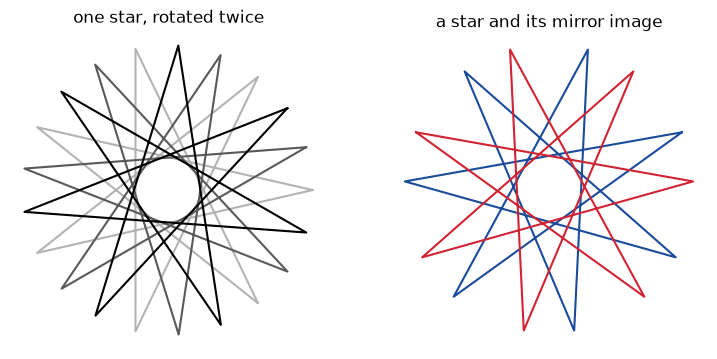

In [7]:
# left: rotation is adding to the angle; right: reflection is negating x
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for step in range(3):
    xs, ys = star_polygon_points(0, 0, 1.0, 7, 3, rotation=step * 0.3)
    shade = str(0.7 - step * 0.35)        # light gray to black
    axes[0].plot(xs, ys, color=shade, linewidth=1.5)
axes[0].set_title("one star, rotated twice")

xs, ys = star_polygon_points(0, 0, 1.0, 7, 3, rotation=0.4)
mirrored_xs = []
for x in xs:
    mirrored_xs.append(-x)                # the mirror: negate every x
axes[1].plot(xs, ys, color="#1B4B9B", linewidth=1.5)
axes[1].plot(mirrored_xs, ys, color="#D02433", linewidth=1.5)
axes[1].set_title("a star and its mirror image")

for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

## Build-up: rosettes

Try `star_polygon_points` with $n = 6, k = 2$ and you hit a snag: after three jumps (0, 2, 4) you are back at corner 0, and all you get is a triangle. The six-pointed star cannot be drawn in one stroke; whenever $n$ and $k$ share a divisor greater than 1, the path closes early.

The fix is older than the notation: **overlay rotated copies.** Two triangles, one turned by 60°, make the hexagram. Two squares, one turned by 45°, make the eight-pointed star that Islamic art knows as *khatam*, everywhere in the Alhambra. A motif made of rotated copies of a shape is called a **rosette**, and it is our first compound machine: `draw_rosette` calls `polygon_points` in a loop.

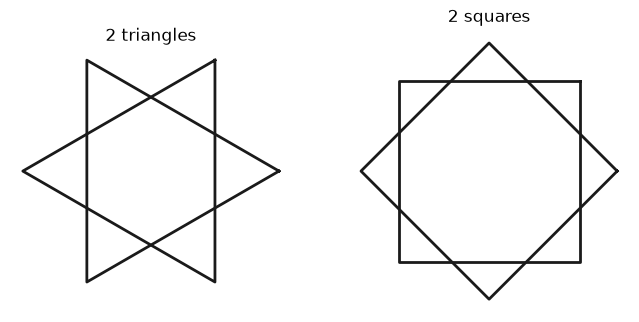

In [8]:
# a rosette: n_copies copies of an n-gon, each rotated a step further
def draw_rosette(ax, cx, cy, radius, n_sides, n_copies, color, linewidth=1.5):
    for copy in range(n_copies):
        rotation = 2 * math.pi / n_sides / n_copies * copy
        xs, ys = polygon_points(cx, cy, radius, n_sides, rotation)
        ax.plot(xs, ys, color=color, linewidth=linewidth)

# two triangles make the hexagram, two squares make the khatam
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_rosette(axes[0], 0, 0, 1.0, 3, 2, "#1A1A1A", linewidth=2)
draw_rosette(axes[1], 0, 0, 1.0, 4, 2, "#1A1A1A", linewidth=2)
axes[0].set_title("2 triangles")
axes[1].set_title("2 squares")
for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

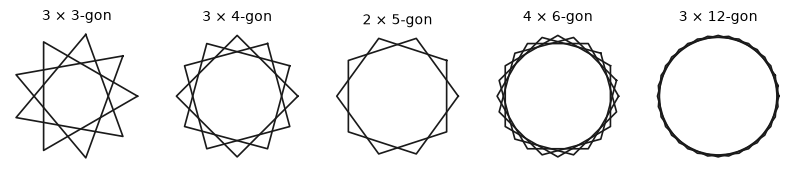

In [9]:
# more copies, more lace: a row of rosettes
fig, axes = plt.subplots(1, 5, figsize=(10, 2.4))
for position, n_sides, n_copies in [(0, 3, 3), (1, 4, 3), (2, 5, 2), (3, 6, 4), (4, 12, 3)]:
    ax = axes[position]
    draw_rosette(ax, 0, 0, 1.0, n_sides, n_copies, "#1A1A1A", linewidth=1.2)
    ax.set_title(f"{n_copies} × {n_sides}-gon", fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")
plt.show()

## Build-up: tiling the plane

A single rosette is a medallion; ornament begins when it **repeats**. The machinery is the nested row/column loop you already know from *Schotter* in chapter 1: for every row and every column, draw the motif at position (column × spacing, row × spacing). This is a **rectangular lattice** (Gitter): translation in two directions. From here on we also bring in the course package from chapter 1: the paper-white ground for artworks, and the palettes we will need shortly.

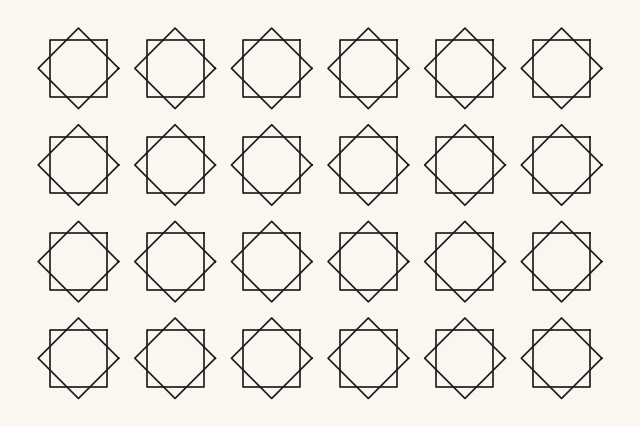

In [10]:
# the same rosette repeated on a rectangular lattice
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

spacing = 2.4
fig, ax = plt.subplots(figsize=(8, 5.4), facecolor=PAPER)
for row in range(4):
    for col in range(6):
        draw_rosette(ax, col * spacing, row * spacing, 1.0, 4, 2, "#1A1A1A",
                     linewidth=1.2)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## The hexagonal lattice

Rectangular repetition suits four-fold motifs, but sixes and threes ask for a different grid. In a **hexagonal lattice**, every second row shifts sideways by half the spacing, and the rows move closer together by a factor of $\sqrt{3}/2 \approx 0.866$, so that every motif sits at the same distance from six neighbors instead of four. It is the packing of honeycombs and pennies on a table, and Islamic six-pointed ornament lives on it.

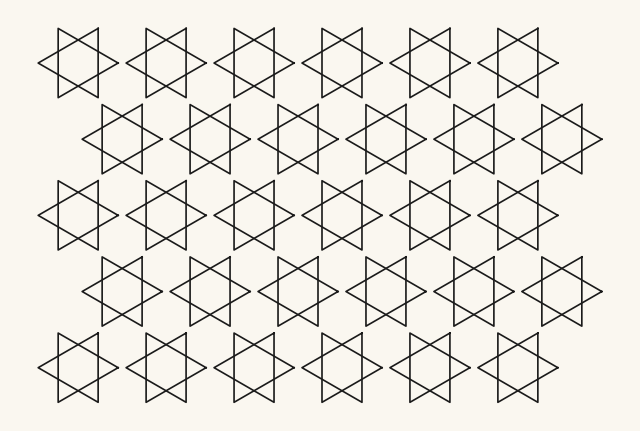

In [11]:
# hexagonal lattice: odd rows shift by half a step, rows squeeze together
spacing = 2.2
row_height = spacing * math.sqrt(3) / 2
fig, ax = plt.subplots(figsize=(8, 5.9), facecolor=PAPER)
for row in range(5):
    for col in range(6):
        cx = col * spacing
        if row % 2 == 1:
            cx = cx + spacing / 2        # the sideways shift of odd rows
        draw_rosette(ax, cx, row * row_height, 1.0, 3, 2, "#1A1A1A",
                     linewidth=1.2)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Color by position

The tilings so far are line drawings in one ink. Ornament traditions rarely stop there: color is assigned **by symmetry position**, so that the eye picks up larger rhythms across the pattern. The simplest recipe: give the motif at (row, col) the palette color number `(row + col) % len(palette)`.

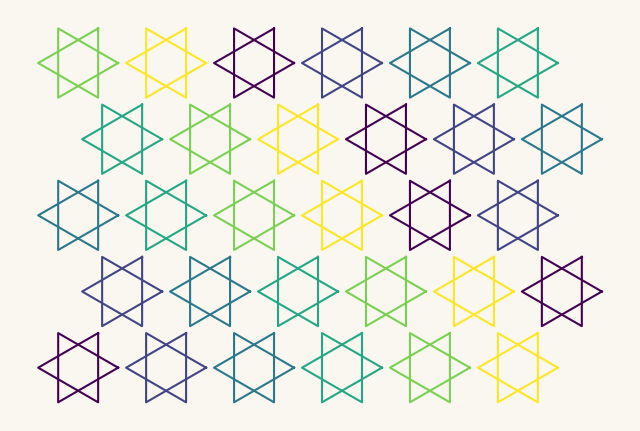

In [12]:
# color each motif by its position in the lattice
palette = PALETTES["viridis"]
spacing = 2.2
row_height = spacing * math.sqrt(3) / 2
fig, ax = plt.subplots(figsize=(8, 5.9), facecolor=PAPER)
for row in range(5):
    for col in range(6):
        cx = col * spacing
        if row % 2 == 1:
            cx = cx + spacing / 2
        color = palette[(row + col) % len(palette)]
        draw_rosette(ax, cx, row * row_height, 1.0, 3, 2, color, linewidth=1.5)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Diagonal stripes of color emerge that no line of code asked for directly: `(row + col)` is constant along diagonals, so equal colors line up. Try `(row + 2 * col)` or `row % 2` in the playground and watch the rhythm change.

## Playground

Everything above, folded into one generator. You may notice something missing: there is no `seed` parameter. Like chapter 0's stripes, a symmetry pattern contains no chance, so every run is identical; the parameters *are* the artwork. Chance returns next chapter.

In [13]:
# the finished generator: a rosette pattern on a square or hexagonal lattice
def rosette_tiling(rows=5, cols=6, n_sides=3, n_copies=2, motif_radius=1.0,
                   spacing=2.2, lattice="hex", palette_name="viridis",
                   linewidth=1.5):
    palette = PALETTES[palette_name]
    if lattice == "hex":
        row_height = spacing * math.sqrt(3) / 2
    else:
        row_height = spacing
    width = (cols - 1) * spacing + 2 * motif_radius
    height = (rows - 1) * row_height + 2 * motif_radius
    fig, ax = plt.subplots(figsize=(8, 8 * height / width), facecolor=PAPER)
    for row in range(rows):
        for col in range(cols):
            cx = col * spacing
            if lattice == "hex" and row % 2 == 1:
                cx = cx + spacing / 2
            color = palette[(row + col) % len(palette)]
            draw_rosette(ax, cx, row * row_height, motif_radius,
                         n_sides, n_copies, color, linewidth)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

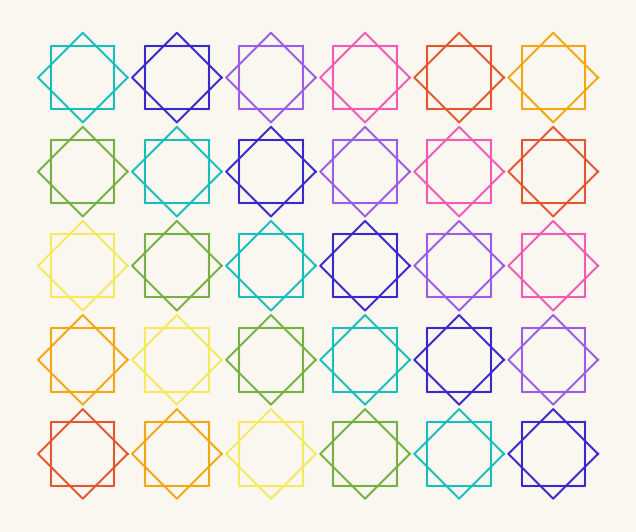

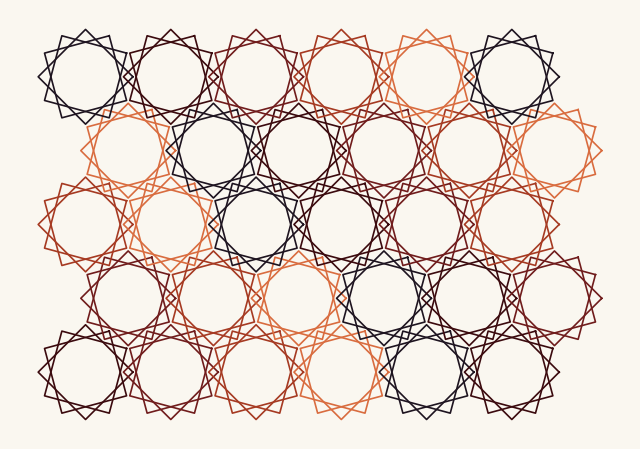

In [14]:
# temperament 1 and 2: khatam medallions on a square grid vs twelve-point lace
art_1 = rosette_tiling(rows=5, cols=6, n_sides=4, n_copies=2, spacing=2.1,
                       lattice="square", palette_name="kelly")
art_2 = rosette_tiling(rows=5, cols=6, n_sides=4, n_copies=3, spacing=1.8,
                       lattice="hex", palette_name="rothko_dark", linewidth=1.2)

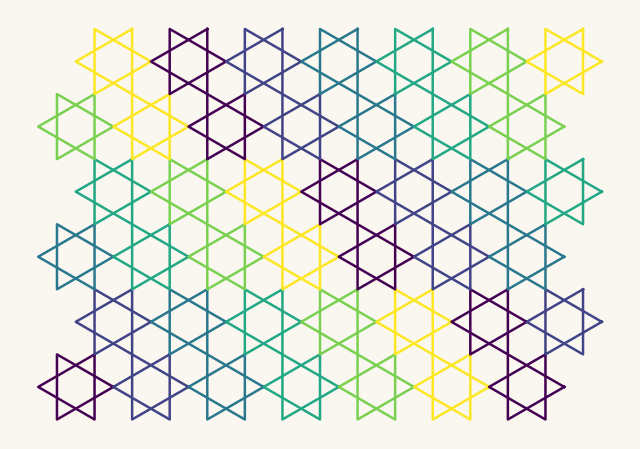

In [15]:
# temperament 3: hexagram rosettes at exactly interlocking spacing
art_3 = rosette_tiling(rows=6, cols=7, n_sides=3, n_copies=2, spacing=2.0,
                       lattice="hex", palette_name="viridis", linewidth=1.8)

## The showpiece: stars and hexagons, filled

For the final pattern we switch from line drawing to **filled** shapes, which is where a tiling starts to look like tilework. The construction uses everything from today:

- a six-pointed star at every point of a hexagonal lattice, drawn as a rosette of two filled triangles (`ax.fill` instead of `ax.plot`),
- with tip radius equal to half the lattice spacing, so neighboring stars touch tip to tip,
- and a small hexagon nested into the gaps above and below each star. Geometry does the bookkeeping: the hexagon's corner radius is $r/\sqrt{3}$, which lands its corners exactly in the stars' notches.

Two palettes are offered below; the pattern reads completely differently depending on whether the stars or the hexagons carry the stronger color. Figure and ground trade places, an effect Escher built a career on.

The generator cell is the densest of the chapter, on purpose: run it, enjoy the result, and read it line by line at home. The three bullets above are all you need to follow along in class.

In [16]:
# the showpiece generator: a star-and-hexagon tiling, filled
def star_and_hexagon(rows=12, cols=7, radius=1.0, palette_name="bauhaus",
                     line_color="#1A1A1A", linewidth=1.4):
    palette = PALETTES[palette_name]
    spacing = 2 * radius                      # stars touch tip to tip
    row_height = spacing * math.sqrt(3) / 2
    hex_radius = radius / math.sqrt(3)        # corners land in the stars' notches
    figure_height = 7 * (rows - 2) * row_height / ((cols - 2) * spacing)
    fig, ax = plt.subplots(figsize=(7, figure_height), facecolor=PAPER)
    for row in range(rows + 1):
        for col in range(cols + 1):
            cx = col * spacing + (row % 2) * radius
            cy = row * row_height
            for rotation in [0.0, math.pi / 3]:       # two triangles = one star
                xs, ys = polygon_points(cx, cy, radius, 3, rotation)
                ax.fill(xs, ys, color=palette[0])
                ax.plot(xs, ys, color=line_color, linewidth=linewidth)
            for direction, color in [(1, palette[1]), (-1, palette[2])]:
                xs, ys = polygon_points(cx + radius, cy + direction * hex_radius,
                                        hex_radius, 6, math.pi / 6)
                ax.fill(xs, ys, color=color)
                ax.plot(xs, ys, color=line_color, linewidth=linewidth)
    ax.set_xlim(spacing, (cols - 1) * spacing)        # crop to an endless field
    ax.set_ylim(row_height, (rows - 1) * row_height)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

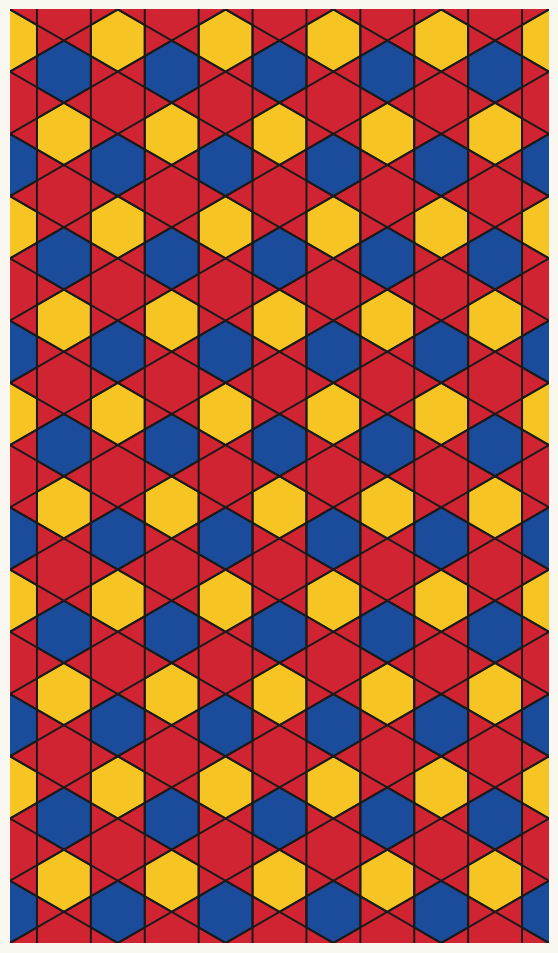

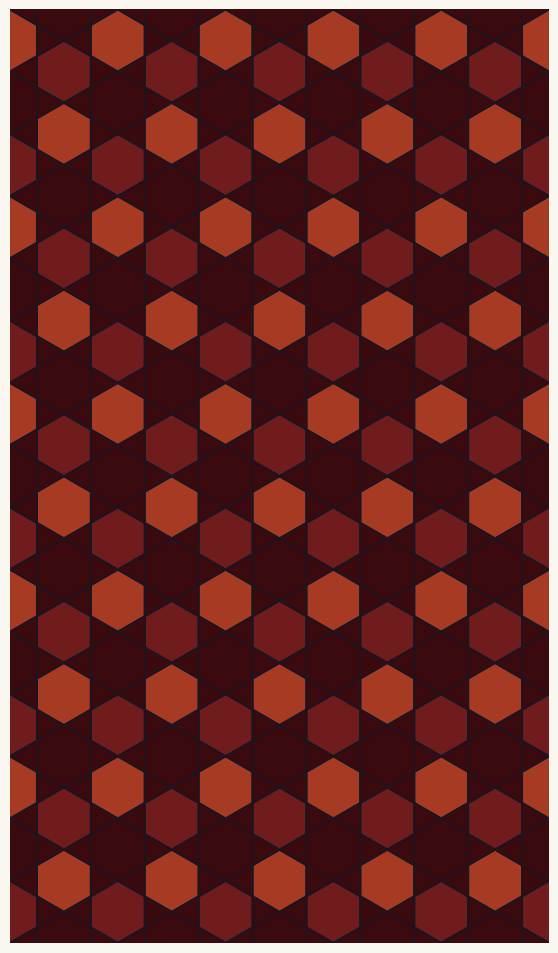

In [17]:
# the same pattern in two palettes -- watch figure and ground trade places
art_4 = star_and_hexagon(rows=12, cols=7, palette_name="bauhaus")
art_5 = star_and_hexagon(rows=12, cols=7, palette_name="rothko_dark",
                         line_color="#1E1420")

**Look and compare.** In the Bauhaus version, do you see red stars on a blue-and-yellow ground, or colored hexagons pinned by dark stars? Does the answer flip in the Rothko version? Among the line tilings, `art_3` uses hexagram rosettes at exactly interlocking spacing: cover it half with your hand and compare its rhythm with `art_2`. Which pattern feels woven, which feels printed, and can you say *which parameter* is responsible?

## Export your artwork

Choose your generator (`rosette_tiling` or `star_and_hexagon`), tune the parameters and palette, replace `yourname`, and run the cell; the print-quality PNG lands in `assets/outputs/`.

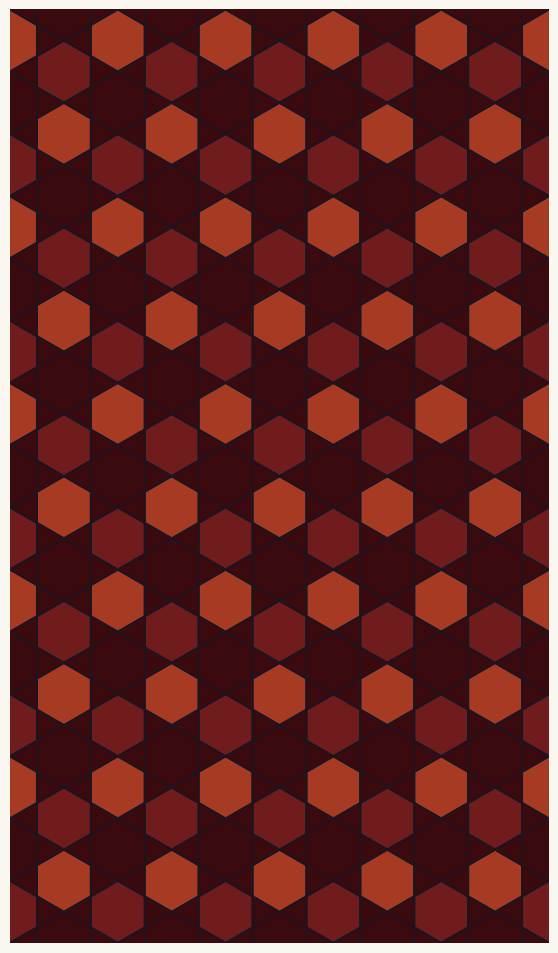

saved: assets/outputs/ch03_yourname.png


In [18]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = star_and_hexagon(rows=12, cols=7, palette_name="rothko_dark",
                              line_color="#1E1420")
saved_path = save_artwork(my_artwork, "yourname", chapter=3)

## Exercises

**(a) Parameter exploration: make them interlock.** Run `rosette_tiling(n_sides=3, n_copies=2, lattice="hex", spacing=3.0)`: the hexagrams float separately. Lower `spacing` in small steps. At which value do the star tips exactly touch? The motif radius is 1.0; can you explain the touching value from the geometry? What happens below it?

**(b) Code modification: glide reflection.** Our rosettes are so symmetric that a mirror changes nothing you can see. Use this deliberately lopsided "flag" motif instead:

```python
flag_xs = [0.0, 0.0, 0.7, 0.0]
flag_ys = [0.0, 1.0, 0.75, 0.5]
```

First tile it on a rectangular lattice (all flags identical: wallpaper at its most boring). Then add **glide reflection**: every odd row gets the motif *mirrored* (negate the x-coordinates, as in the rotation-and-reflection cell) *and shifted* by half the spacing. The result is the footprints-in-snow pattern: left, right, left, right.

<details><summary>Solution</summary>

```python
flag_xs = [0.0, 0.0, 0.7, 0.0]
flag_ys = [0.0, 1.0, 0.75, 0.5]

def flag_tiling(rows=5, cols=8, spacing=1.5, glide=True):
    fig, ax = plt.subplots(figsize=(8, 8 * rows / cols), facecolor=PAPER)
    for row in range(rows):
        for col in range(cols):
            mirror = 1
            shift = 0.0
            if glide and row % 2 == 1:
                mirror = -1               # reflect the motif...
                shift = spacing / 2       # ...and glide it half a step
            xs = []
            ys = []
            for i in range(len(flag_xs)):
                xs.append(col * spacing + shift + mirror * flag_xs[i])
                ys.append(row * spacing + flag_ys[i])
            ax.plot(xs, ys, color="#1A1A1A", linewidth=2)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

flag_tiling(glide=False)
flag_tiling(glide=True)
```

Reflection alone would stack the mirrored rows directly above the originals; the half-step shift is what makes the footsteps walk. Both versions belong to wallpaper group *pg*, one of the 17: the shift changes the look, not the symmetry class.
</details>

**(c) Creative challenge: design a motif and tile it.** Compose your own motif from polygons, stars, and rosettes (overlay two or three calls with different sizes and rotations), then repeat it on the lattice of your choice with a color rule of your choice. Name the result the way Owen Jones would: plate number, culture, epoch, all invented.

## Further reading

- Owen Jones, [*The Grammar of Ornament*](https://archive.org/details/grammarornament00Jone) (1856): the full chromolithographed atlas, digitized; browse the Moresque plates and read the 37 propositions.
- Peter J. Lu and Paul J. Steinhardt, ["Decagonal and Quasi-Crystalline Tilings in Medieval Islamic Architecture"](https://doi.org/10.1126/science.1135491), *Science* 315 (2007): the girih-tile argument, and worth reading alongside the published critical comments.
- Eric Broug, *Islamic Geometric Patterns* (Thames & Hudson, 2008): compass-and-straightedge constructions you can follow by hand; his [School of Islamic Geometric Design](https://www.broug.com/) offers free video tutorials.
- Doris Schattschneider, *M.C. Escher: Visions of Symmetry* (1990): Escher's Alhambra notebooks and his own symmetry system, reproduced page by page.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

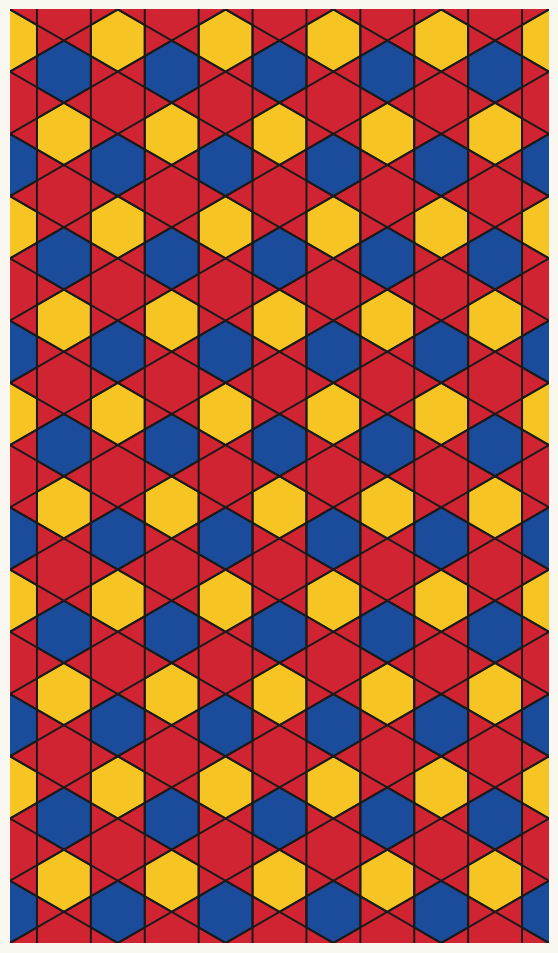

saved: assets/outputs/ch03_showpiece.png


In [19]:
# regenerate this chapter's showpiece: the star-and-hexagon tiling
showpiece = star_and_hexagon(rows=12, cols=7, palette_name="bauhaus")
saved_path = save_artwork(showpiece, "showpiece", chapter=3)